In [31]:
from google.colab import files
import io
import os
import re
import html
import unicodedata
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold

print("Upload either:")
print("  • Train.csv and Test.csv, OR")
print("  • the challenge ZIP containing those files.")
uploaded = files.upload()

Upload either:
  • Train.csv and Test.csv, OR
  • the challenge ZIP containing those files.


Saving Train.csv to Train (2).csv
Saving Test.csv to Test (2).csv


In [32]:
# Locate and load Train.csv / Test.csv from uploaded files.
uploaded_names = list(uploaded.keys())

train_name = next((n for n in uploaded_names if "train" in os.path.basename(n).lower()), None)
test_name = next((n for n in uploaded_names if "test" in os.path.basename(n).lower()), None)

if train_name and test_name:
    train = pd.read_csv(io.BytesIO(uploaded[train_name]))
    test = pd.read_csv(io.BytesIO(uploaded[test_name]))
else:
    zip_name = next((n for n in uploaded_names if n.lower().endswith(".zip")), None)
    if zip_name is None:
        raise FileNotFoundError(
            "Please upload Train.csv + Test.csv, or upload the challenge ZIP file."
        )

    with zipfile.ZipFile(io.BytesIO(uploaded[zip_name])) as z:
        members = {os.path.basename(name).lower(): name for name in z.namelist()}
        train_member = next((val for key, val in members.items() if "train.csv" in key), None)
        test_member = next((val for key, val in members.items() if "test.csv" in key), None)
        if not train_member or not test_member:
            raise FileNotFoundError("The ZIP does not contain both Train.csv and Test.csv.")
        with z.open(train_member) as f:
            train = pd.read_csv(f)
        with z.open(test_member) as f:
            test = pd.read_csv(f)

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")
print("\nTrain columns:", train.columns.tolist())
print("Test columns :", test.columns.tolist())

Train shape: (39650, 3)
Test shape : (15581, 2)

Train columns: ['Tweet_ID', 'tweet', 'type']
Test columns : ['Tweet_ID', 'tweet']


In [33]:
# Basic validation of the expected schema
required_train_cols = {"Tweet_ID", "tweet", "type"}
required_test_cols = {"Tweet_ID", "tweet"}

missing_train = required_train_cols - set(train.columns)
missing_test = required_test_cols - set(test.columns)

if missing_train:
    raise ValueError(f"Missing training columns: {missing_train}")
if missing_test:
    raise ValueError(f"Missing test columns: {missing_test}")

print("Expected columns are present.")
display(train.head())

Expected columns are present.


,Tweet_ID,tweet,type
0,ID_0022DWKP,Had a dream i got raped last night. By a guy i...,sexual_violence
1,ID_00395QYM,he thought the word raped means sex and told m...,sexual_violence
2,ID_003EOSSF,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,ID_004BBHOD,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,ID_004F7516,Chessy Prout can do better by telling the trut...,sexual_violence


## 1. Dataset structure and data quality

We first check missing values, duplicate rows, duplicate IDs, and duplicate tweet text. These checks are important because duplicate text can cause information leakage if the same content appears in both training and validation data.

In [34]:
print("TRAINING DATA INFORMATION")
train.info()

print("\nMISSING VALUES")
print(train.isna().sum())

print("\nDUPLICATES")
print("Duplicate full rows :", train.duplicated().sum())
print("Duplicate Tweet_IDs  :", train["Tweet_ID"].duplicated().sum())
print("Duplicate tweet text:", train["tweet"].duplicated().sum())

TRAINING DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39650 entries, 0 to 39649
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tweet_ID  39650 non-null  object
 1   tweet     39650 non-null  object
 2   type      39650 non-null  object
dtypes: object(3)
memory usage: 929.4+ KB

MISSING VALUES
Tweet_ID    0
tweet       0
type        0
dtype: int64

DUPLICATES
Duplicate full rows : 0
Duplicate Tweet_IDs  : 0
Duplicate tweet text: 8


In [35]:
# Basic social-media/text characteristics
tweet_text = train["tweet"].astype(str)

quality_summary = pd.DataFrame({
    "Measure": [
        "Training rows",
        "Test rows",
        "Missing tweets",
        "Missing labels",
        "Duplicate full rows",
        "Duplicate Tweet_IDs",
        "Exact duplicate tweet texts",
        "Tweets with HTML entities",
        "Tweets containing emojis",
        "Tweets containing non-ASCII characters",
    ],
    "Value": [
        len(train),
        len(test),
        train["tweet"].isna().sum(),
        train["type"].isna().sum(),
        train.duplicated().sum(),
        train["Tweet_ID"].duplicated().sum(),
        train["tweet"].duplicated().sum(),
        tweet_text.str.contains(r"&[A-Za-z#0-9]+;", regex=True).sum(),
        tweet_text.str.contains(
            r"[\U0001F300-\U0001FAFF\U00002700-\U000027BF\U00002600-\U000026FF]",
            regex=True
        ).sum(),
        tweet_text.apply(lambda x: any(ord(ch) > 127 for ch in x)).sum(),
    ]
})

display(quality_summary)

,Measure,Value
0,Training rows,39650
1,Test rows,15581
2,Missing tweets,0
3,Missing labels,0
4,Duplicate full rows,0
5,Duplicate Tweet_IDs,0
6,Exact duplicate tweet texts,8
7,Tweets with HTML entities,3299
8,Tweets containing emojis,4433
9,Tweets containing non-ASCII characters,16678


## 2. Class distribution

Because this is a multi-class classification task, the distribution of the target classes is important. A severe imbalance means that accuracy alone can be misleading and that the modelling team should consider class-aware evaluation and/or balancing strategies.

,type,count,percentage
0,sexual_violence,32648,82.34
1,Physical_violence,5946,15.00
2,emotional_violence,651,1.64
3,economic_violence,217,0.55
4,Harmful_Traditional_practice,188,0.47


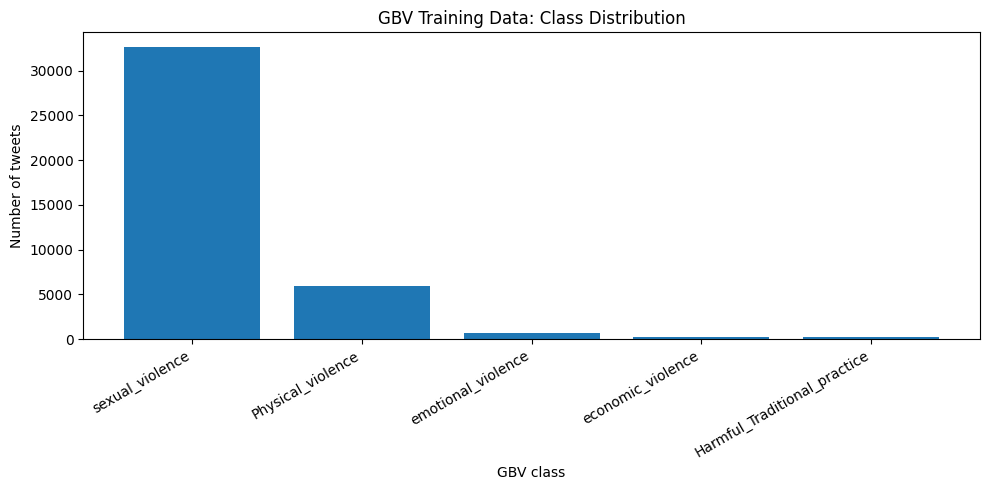

In [36]:
class_counts = train["type"].value_counts().rename_axis("type").reset_index(name="count")
class_counts["percentage"] = (class_counts["count"] / len(train) * 100).round(2)

display(class_counts)

plt.figure(figsize=(10, 5))
plt.bar(class_counts["type"], class_counts["count"])
plt.title("GBV Training Data: Class Distribution")
plt.xlabel("GBV class")
plt.ylabel("Number of tweets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Record the important result here after running the cell:

> The class distribution is highly imbalanced, with one class representing the majority of the training data and several minority classes having relatively few examples. This has implications for model training, validation and metric selection.

## 3. Tweet/sequence length analysis

Tweet length matters for sequential models because it affects the number of tokens each model must process. We inspect both character count and approximate word count.

In [37]:
train["char_len"] = train["tweet"].astype(str).str.len()
train["word_len"] = train["tweet"].astype(str).str.split().str.len()

length_stats = train[["char_len", "word_len"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

display(length_stats)

class_length_summary = train.groupby("type").agg(
    tweets=("tweet", "size"),
    mean_chars=("char_len", "mean"),
    median_chars=("char_len", "median"),
    mean_words=("word_len", "mean"),
    median_words=("word_len", "median")
).round(2)

display(class_length_summary)

,char_len,word_len
count,39650.00,39650.00
mean,199.40,38.89
std,76.63,15.15
min,10.00,2.00
50%,225.00,43.00
75%,270.00,52.00
90%,279.00,56.00
95%,280.00,58.00
99%,286.00,61.00
max,308.00,68.00


,tweets,mean_chars,median_chars,mean_words,median_words
type,,,,,
Harmful_Traditional_practice,188,191.77,210.5,33.92,35.5
Physical_violence,5946,122.68,102.0,23.30,19.0
economic_violence,217,205.38,232.0,40.53,46.0
emotional_violence,651,202.65,225.0,38.48,42.0
sexual_violence,32648,213.31,241.0,41.75,46.0


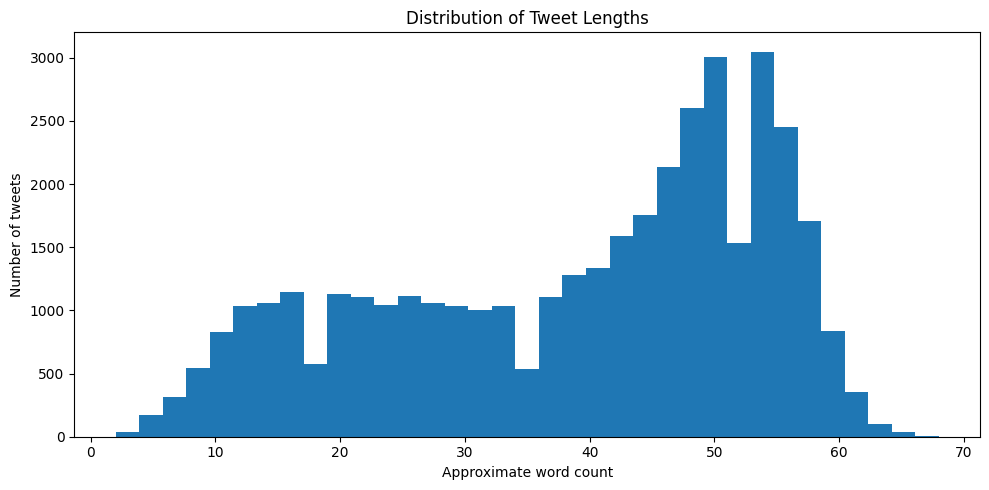

In [38]:
plt.figure(figsize=(10, 5))
plt.hist(train["word_len"], bins=35)
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Approximate word count")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()

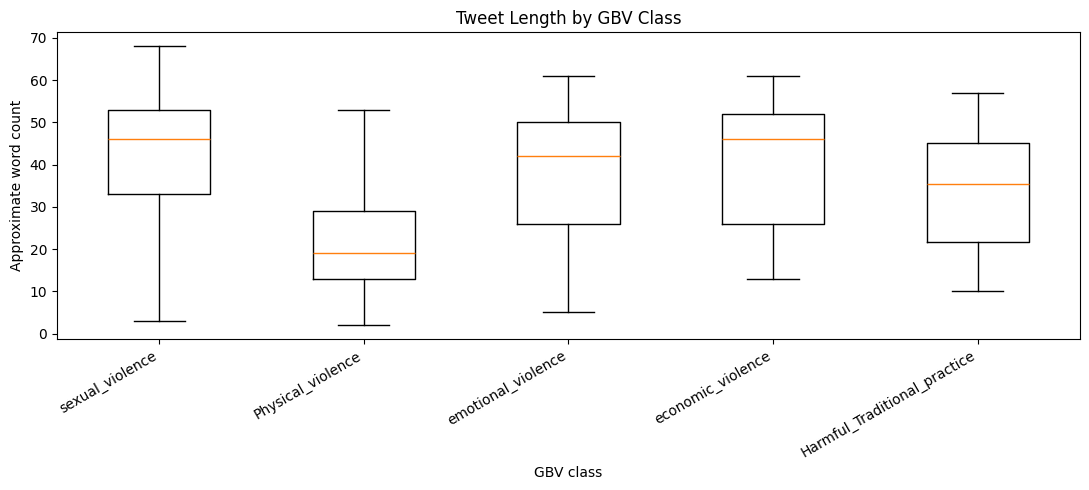

In [39]:
classes = class_counts["type"].tolist()
box_data = [train.loc[train["type"] == cls, "word_len"] for cls in classes]

plt.figure(figsize=(11, 5))
plt.boxplot(box_data, showfliers=False)
plt.title("Tweet Length by GBV Class")
plt.xlabel("GBV class")
plt.ylabel("Approximate word count")
plt.xticks(range(1, len(classes) + 1), classes, rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

These plots can be used to justify the maximum sequence/token length selected by the modelling team. Extremely long tweets are relatively uncommon, so the team can investigate a practical maximum length using the observed distribution rather than choosing one arbitrarily.

## 4. Vocabulary and noisy-text characteristics

Tweets may contain URLs, mentions, punctuation, emojis and spelling variation. We inspect frequent tokens before deciding how much normalization to apply.

In [40]:
def rough_tokens(text):
    return re.findall(r"\b\w+\b", str(text).lower())

token_counter = Counter()
for text in train["tweet"]:
    token_counter.update(rough_tokens(text))

top_tokens = pd.DataFrame(token_counter.most_common(25), columns=["token", "frequency"])
display(top_tokens)

,token,frequency
0,me,55094
1,he,54965
2,i,54327
3,to,38157
4,and,37866
5,the,36146
6,raped,34299
7,a,34122
8,was,25703
9,my,25347


In [41]:
# Inspect common URL/mention/hashtag-style patterns
social_features = pd.DataFrame({
    "Feature": [
        "URLs",
        "User mentions",
        "Hashtags",
        "Repeated punctuation",
    ],
    "Tweets containing feature": [
        train["tweet"].astype(str).str.contains(r"https?://\S+|www\.\S+", regex=True).sum(),
        train["tweet"].astype(str).str.contains(r"@\w+", regex=True).sum(),
        train["tweet"].astype(str).str.contains(r"#\w+", regex=True).sum(),
        train["tweet"].astype(str).str.contains(r"[!?]{2,}|\.{2,}", regex=True).sum(),
    ]
})

social_features["Percentage"] = (
    social_features["Tweets containing feature"] / len(train) * 100
).round(2)

display(social_features)

,Feature,Tweets containing feature,Percentage
0,URLs,4,0.01
1,User mentions,0,0.00
2,Hashtags,0,0.00
3,Repeated punctuation,7831,19.75


## 5. Light text normalization

The normalization below intentionally avoids aggressive deletion of linguistic information. It:
- decodes HTML entities,
- applies Unicode normalization,
- replaces URLs with `<URL>`,
- replaces user mentions with `<USER>`,
- normalizes whitespace.

Punctuation, hashtags, emojis and word order are retained for later model-specific tokenization.

In [42]:
def normalize_tweet(text):
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)

    # Replace URLs
    text = re.sub(r"https?://\S+|www\.\S+", " <URL> ", text)

    # Replace user mentions
    text = re.sub(r"@\w+", " <USER> ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

train["tweet_clean"] = train["tweet"].map(normalize_tweet)
test["tweet_clean"] = test["tweet"].map(normalize_tweet)

display(train[["tweet", "tweet_clean"]].head(10))

,tweet,tweet_clean
0,Had a dream i got raped last night. By a guy i...,Had a dream i got raped last night. By a guy i...
1,he thought the word raped means sex and told m...,he thought the word raped means sex and told m...
2,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...
3,I was sexually abused for 3 years at age 4 to ...,I was sexually abused for 3 years at age 4 to ...
4,Chessy Prout can do better by telling the trut...,Chessy Prout can do better by telling the trut...
5,"Yes men rape women. But women also rape men, y...","Yes men rape women. But women also rape men, y..."
6,"My Husband Beats Me Frequently, Wife Tells Cou...","My Husband Beats Me Frequently, Wife Tells Cou..."
7,Pretty sure he raped a 16yr old girl with 2 fr...,Pretty sure he raped a 16yr old girl with 2 fr...
8,TW sorry to hear that and yeah he recently th...,TW sorry to hear that and yeah he recently thr...
9,"""I understand that... My father was abusive as...","""I understand that... My father was abusive as..."


In [43]:
# Check what normalization changed and whether it created duplicate text groups.
normalized_duplicate_count = train["tweet_clean"].duplicated().sum()
duplicate_groups_with_conflicting_labels = (
    train.groupby("tweet_clean")["type"].nunique().gt(1).sum()
)
train_test_overlap = len(set(train["tweet_clean"]) & set(test["tweet_clean"]))

normalization_summary = pd.DataFrame({
    "Measure": [
        "Duplicate normalized texts",
        "Normalized-text groups with conflicting labels",
        "Normalized-text overlap between train and test",
    ],
    "Value": [
        normalized_duplicate_count,
        duplicate_groups_with_conflicting_labels,
        train_test_overlap,
    ]
})

display(normalization_summary)

,Measure,Value
0,Duplicate normalized texts,458
1,Normalized-text groups with conflicting labels,2
2,Normalized-text overlap between train and test,9


## 6. Duplicate-aware stratified validation split

A random split can place identical normalized tweets in both training and validation, which can inflate validation performance. We therefore group by normalized tweet text while preserving the target distribution as much as possible.

The modelling team should use these exact exported train/validation files so that all models are compared on the same split.

In [44]:
groups = train["tweet_clean"].values
y = train["type"].values

sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(sgkf.split(train, y, groups))

train_model = train.iloc[train_idx].copy()
validation_model = train.iloc[val_idx].copy()

print("Train split:", train_model.shape)
print("Validation split:", validation_model.shape)

overlap = len(
    set(train_model["tweet_clean"]) &
    set(validation_model["tweet_clean"])
)

print("Normalized-text overlap between train and validation:", overlap)

split_summary = pd.concat([
    train_model["type"].value_counts(normalize=True).rename("train_pct") * 100,
    validation_model["type"].value_counts(normalize=True).rename("validation_pct") * 100
], axis=1).round(2)

display(split_summary)

Train split: (35676, 6)
Validation split: (3974, 6)
Normalized-text overlap between train and validation: 0


,train_pct,validation_pct
type,,
sexual_violence,82.32,82.54
Physical_violence,15.03,14.70
emotional_violence,1.63,1.79
economic_violence,0.56,0.45
Harmful_Traditional_practice,0.47,0.53


## 7. Export files for the modelling team

The files below provide a common starting point for all three models. The modelling team can apply model-specific tokenization/feature extraction to the `tweet_clean` column.

In [45]:
output_dir = "GBV_Person1_Output"
os.makedirs(output_dir, exist_ok=True)

train_model[["Tweet_ID", "tweet", "tweet_clean", "type"]].to_csv(
    f"{output_dir}/train_model.csv", index=False
)

validation_model[["Tweet_ID", "tweet", "tweet_clean", "type"]].to_csv(
    f"{output_dir}/validation_model.csv", index=False
)

test[["Tweet_ID", "tweet", "tweet_clean"]].to_csv(
    f"{output_dir}/test_for_prediction.csv", index=False
)

class_counts.to_csv(
    f"{output_dir}/class_distribution.csv", index=False
)

class_length_summary.to_csv(
    f"{output_dir}/length_summary_by_class.csv"
)

quality_summary.to_csv(
    f"{output_dir}/data_quality_summary.csv", index=False
)

print("Exported files:")
for filename in sorted(os.listdir(output_dir)):
    print(" -", filename)

Exported files:
 - class_distribution.csv
 - data_quality_summary.csv
 - length_summary_by_class.csv
 - test_for_prediction.csv
 - train_model.csv
 - validation_model.csv
